# 🛋️ 가구 제거 파이프라인 (Google Drive 연동)

### 📌 실행 순서
| 셀 | 언제? | 설명 |
|---|---|---|
| **셀 1** | 최초 1회만 | Drive에 모델/코드 설치 |
| **셀 2-A** | 런타임 시작할 때마다 | Pillow 설치 + 자동 재시작 |
| **셀 2-B** | 셀 2-A 재시작 후 | 환경 복원 + 모델 로드 |
| **셀 3~6** | 작업할 때마다 | 이미지 업로드 → 제거 → 저장 |

In [ ]:
# ============================================================
# 셀 1: 최초 1회만 실행 (Drive에 모델 저장)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DIR = '/content/drive/MyDrive/furniture_remover'
SAM2_DIR  = f'{DRIVE_DIR}/sam2'
LAMA_DIR  = f'{DRIVE_DIR}/lama_local'
MODEL_DIR = f'{DRIVE_DIR}/lama_model'

os.makedirs(DRIVE_DIR, exist_ok=True)

# ── SAM2 클론 ──────────────────────────────
if not os.path.exists(SAM2_DIR):
    print('📦 SAM2 클론 중...')
    !git clone https://github.com/facebookresearch/sam2.git {SAM2_DIR}
else:
    print('✅ SAM2 이미 존재!')

# ── SAM2 체크포인트 ────────────────────────
ckpt_path = f'{SAM2_DIR}/checkpoints/sam2.1_hiera_large.pt'
if not os.path.exists(ckpt_path):
    print('⬇️ SAM2 체크포인트 다운로드 중...')
    os.makedirs(f'{SAM2_DIR}/checkpoints', exist_ok=True)
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt \
        -O {ckpt_path}
else:
    print('✅ SAM2 체크포인트 이미 존재!')

# ── LaMa 코드 클론 + 패치 ─────────────────
if not os.path.exists(LAMA_DIR):
    print('📦 LaMa 클론 중...')
    !git clone https://github.com/advimman/lama.git {LAMA_DIR}

    # aug.py 패치 (최신 albumentations 호환)
    aug_patch = '''import albumentations as A
from albumentations import DualTransform
import numpy as np

def to_tuple(param, low=None):
    if isinstance(param, tuple):
        return param
    if low is None:
        return (-param, param)
    return (low, param)

class IAAAffine2(DualTransform):
    def __init__(self, scale=1.0, always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.scale = to_tuple(scale, 1.0) if not isinstance(scale, tuple) else scale
    def apply(self, img, **params):
        return img
    def apply_to_mask(self, img, **params):
        return img
    def get_transform_init_args_names(self):
        return ("scale",)

class IAAPerspective2(DualTransform):
    def __init__(self, scale=(0.05, 0.1), always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.scale = scale
    def apply(self, img, **params):
        return img
    def apply_to_mask(self, img, **params):
        return img
    def get_transform_init_args_names(self):
        return ("scale",)
'''
    with open(f'{LAMA_DIR}/saicinpainting/training/data/aug.py', 'w') as f:
        f.write(aug_patch)

    # torch.load 패치 (weights_only 경고 해결)
    init_path = f'{LAMA_DIR}/saicinpainting/training/trainers/__init__.py'
    with open(init_path) as f:
        content = f.read()
    content = content.replace(
        'torch.load(path, map_location=map_location)',
        'torch.load(path, map_location=map_location, weights_only=False)'
    )
    with open(init_path, 'w') as f:
        f.write(content)
    print('✅ LaMa 클론 + 패치 완료!')
else:
    print('✅ LaMa 이미 존재!')

# ── LaMa 모델 다운로드 ────────────────────
if not os.path.exists(f'{MODEL_DIR}/big-lama'):
    print('⬇️ big-lama 모델 다운로드 중...')
    os.makedirs(MODEL_DIR, exist_ok=True)
    !wget -q --show-progress \
        'https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip' \
        -O {MODEL_DIR}/big-lama.zip
    !unzip -q {MODEL_DIR}/big-lama.zip -d {MODEL_DIR}/
    print('✅ big-lama 모델 완료!')
else:
    print('✅ big-lama 모델 이미 존재!')

print('\n🎉 모든 파일 Drive 저장 완료!')
print('다음부터는 셀 2만 실행하면 됩니다!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ SAM2 이미 존재!
✅ SAM2 체크포인트 이미 존재!
✅ LaMa 이미 존재!
✅ big-lama 모델 이미 존재!

🎉 모든 파일 Drive 저장 완료!
다음부터는 셀 2만 실행하면 됩니다!


In [1]:
# ============================================================
# 셀 2: 런타임 시작할 때마다 실행
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, sys

DRIVE_DIR = '/content/drive/MyDrive/furniture_remover'
SAM2_DIR  = f'{DRIVE_DIR}/sam2'
LAMA_DIR  = f'{DRIVE_DIR}/lama_local'
MODEL_DIR = f'{DRIVE_DIR}/lama_model'

# numpy 먼저 고정 후 런타임 재시작 필요
import numpy as np
if np.__version__ != '1.26.4':
    !pip install -q numpy==1.26.4
    print('⚠️ numpy 재설치 완료 - 런타임 재시작 필요!')
    import os; os.kill(os.getpid(), 9)

# 패키지 설치
print('📦 패키지 설치 중...')
!pip install -q \
    hydra-core==1.3.2 \
    omegaconf==2.3.0 \
    kornia \
    easydict \
    tabulate \
    webdataset \
    albumentations==1.3.1 \
    pytorch-lightning==1.9.5

# SAM2 설치
print('🔧 SAM2 설치 중...')
%cd {SAM2_DIR}
!pip install -q -e .
%cd /content

sys.path.insert(0, SAM2_DIR)
sys.path.insert(0, LAMA_DIR)

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import io

print(f'torch: {torch.__version__}, numpy: {np.__version__}, Pillow: {Image.__version__}')

# SAM2 모델 로드
print('🤖 SAM2 모델 로드 중...')
%cd {SAM2_DIR}
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_model = build_sam2(
    'configs/sam2.1/sam2.1_hiera_l.yaml',
    f'{SAM2_DIR}/checkpoints/sam2.1_hiera_large.pt',
    device='cuda'
)
predictor = SAM2ImagePredictor(sam2_model)
%cd /content

# LaMa 모델 로드
print('🎨 LaMa 모델 로드 중...')
from omegaconf import OmegaConf
from saicinpainting.training.trainers import load_checkpoint

train_config = OmegaConf.load(f'{MODEL_DIR}/big-lama/config.yaml')
train_config.training_model.predict_only = True
train_config.visualizer.kind = 'noop'

lama_model = load_checkpoint(
    train_config,
    f'{MODEL_DIR}/big-lama/models/best.ckpt',
    strict=False,
    map_location='cpu'
)
lama_model.freeze()
lama_model.to('cuda')

print('\n✅ 모든 준비 완료! 셀 3으로 이동하세요!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 패키지 설치 중...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.5 MB/s eta 0:00:00
🔧 SAM2 설치 중...
/content/drive/MyDrive/furniture_remover/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
/content
torch: 2.10.0+cu128, numpy: 1.26.4, Pillow: 9.5.0
🤖 SAM2 모델 로드 중...
/content/drive/MyDrive/furniture_remover/sam2
/content
🎨 LaMa 모델 로드 중...
Detectron v2 is not installed

✅ 모든 준비 완료! 셀 3으로 이동하세요!


📁 방 사진을 업로드하세요!


Saving KakaoTalk_20260312_115356330.jpg to KakaoTalk_20260312_115356330 (1).jpg
리사이즈: 1280x800 → 1024x640


/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 54624 (\N{HANGUL SYLLABLE HAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1548986194.py:34: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.ti

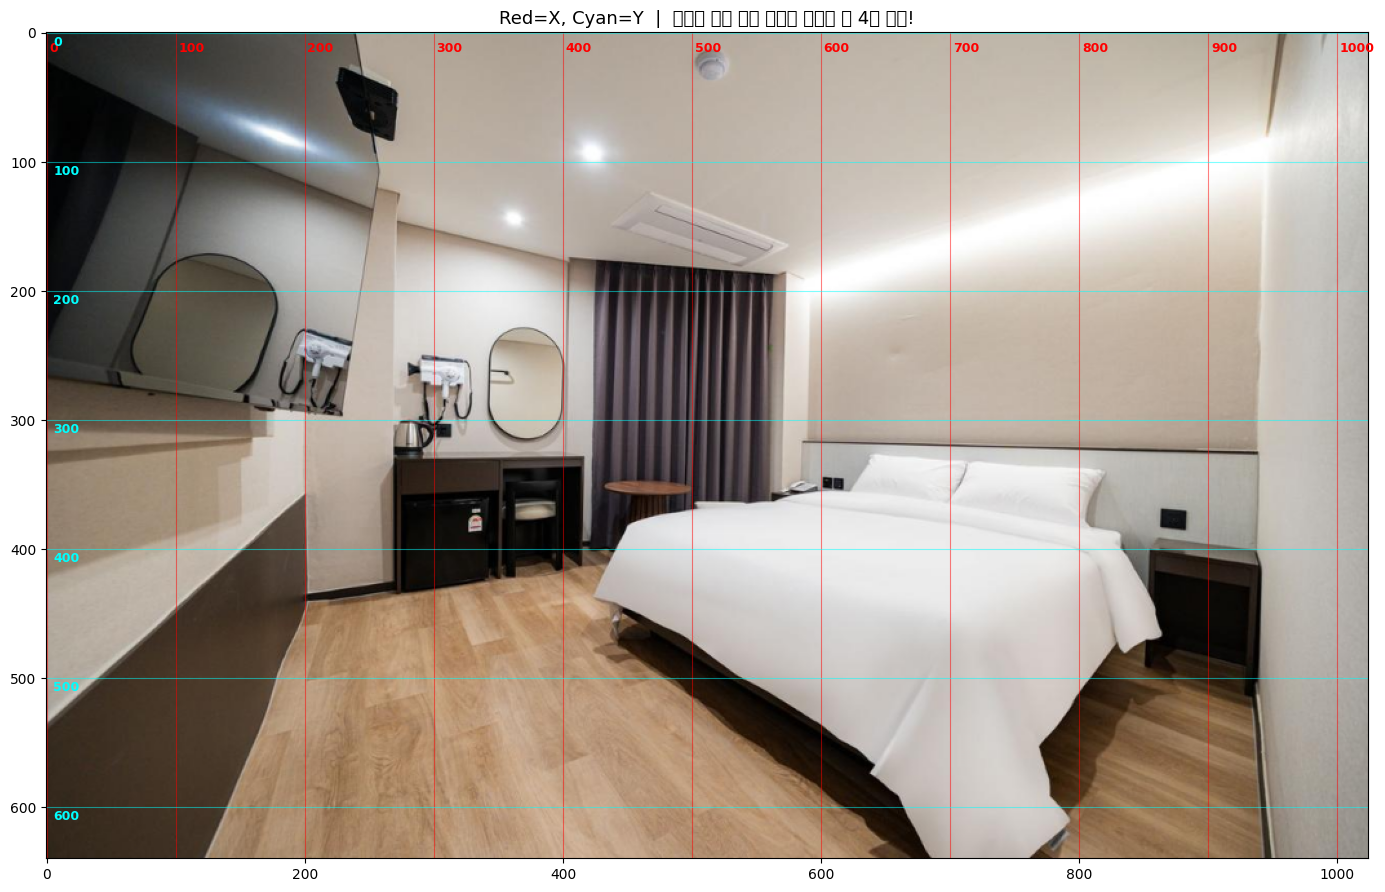

이미지 크기: W=1024, H=640
👆 좌표 확인 후 셀 4의 CLICK_X, CLICK_Y 수정!


In [2]:
# ============================================================
# 셀 3: 이미지 업로드 & 좌표 격자 확인
# ============================================================
%matplotlib inline
from google.colab import files

print('📁 방 사진을 업로드하세요!')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
image_np = np.array(image)

# 리사이즈
MAX_SIZE = 1024
h, w = image_np.shape[:2]
if max(h, w) > MAX_SIZE:
    scale = MAX_SIZE / max(h, w)
    image_np = cv2.resize(image_np, (int(w*scale), int(h*scale)))
    print(f'리사이즈: {w}x{h} → {image_np.shape[1]}x{image_np.shape[0]}')

h, w = image_np.shape[:2]

# 좌표 격자 표시
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(image_np)
for x in range(0, w, 100):
    ax.axvline(x=x, color='red', alpha=0.5, linewidth=0.8)
    ax.text(x+2, 15, str(x), color='red', fontsize=9, fontweight='bold')
for y in range(0, h, 100):
    ax.axhline(y=y, color='cyan', alpha=0.5, linewidth=0.8)
    ax.text(5, y+10, str(y), color='cyan', fontsize=9, fontweight='bold')
ax.set_title('Red=X, Cyan=Y  |  제거할 가구 중심 좌표를 읽어서 셀 4에 입력!', fontsize=13)
plt.tight_layout()
plt.show()

print(f'이미지 크기: W={w}, H={h}')
print('👆 좌표 확인 후 셀 4의 CLICK_X, CLICK_Y 수정!')

마스크 점수: [0.91340935 0.84842443 0.9207405 ]
선택: 2번 (score: 0.921)


/tmp/ipykernel_11898/2552960766.py:47: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/2552960766.py:47: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/2552960766.py:47: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/2552960766.py:47: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


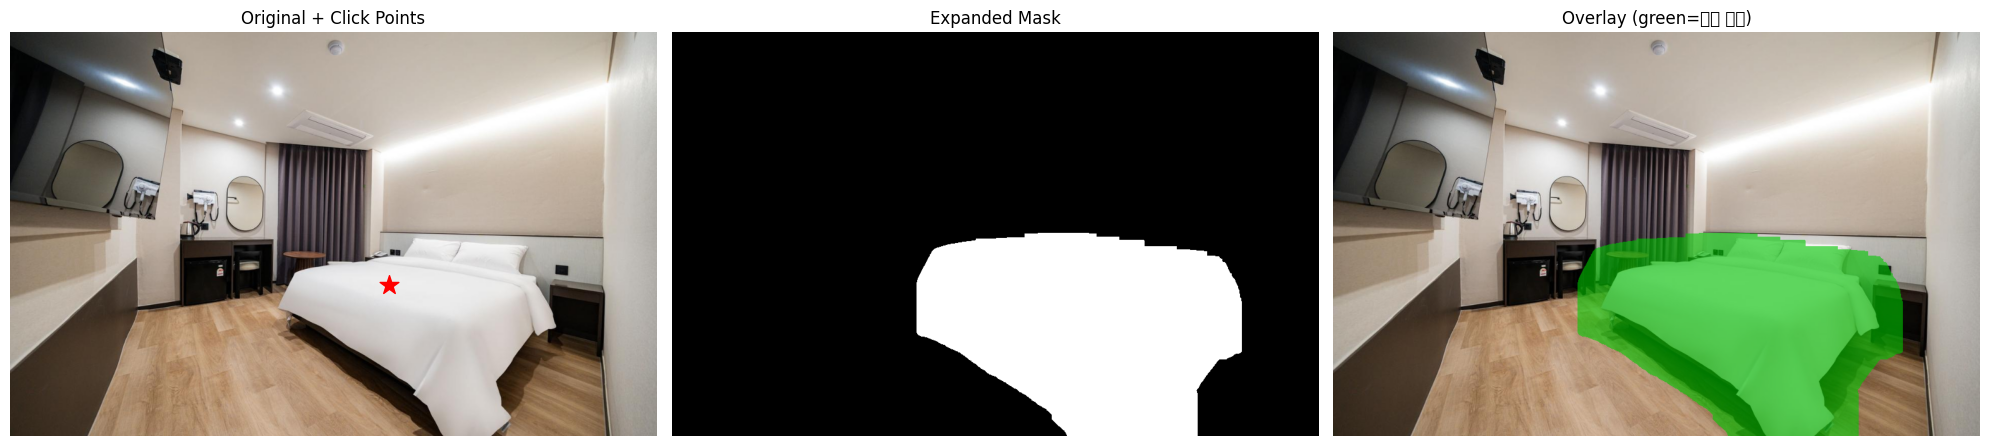

마스크가 가구 전체를 잘 덮으면 셀 5 실행!
부족하면 kernel 크기나 iterations 숫자를 늘려보세요.


In [3]:
# ============================================================
# 셀 4: SAM2로 마스크 생성
# ✏️ 좌표를 위 격자 이미지 보고 수정하세요!
# ============================================================

# ✏️ 여기 수정!
input_points = np.array([
    [600, 400],   # 가구 중심 좌표
    # [700, 500], # 필요하면 추가
])
input_labels = np.array([1] * len(input_points))
USE_MULTI_MASK = len(input_points) == 1

predictor.set_image(image_np)
masks, scores, _ = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=USE_MULTI_MASK,
)

best_idx  = np.argmax(scores)
best_mask = masks[best_idx].astype(bool)

# 마스크 팽창 (가구 프레임/다리까지 포함)
mask_np = (best_mask * 255).astype(np.uint8)
kernel  = np.ones((40, 40), np.uint8)
mask_np = cv2.dilate(mask_np, kernel, iterations=2)
best_mask_expanded = mask_np > 127

print(f'마스크 점수: {scores}')
print(f'선택: {best_idx}번 (score: {scores[best_idx]:.3f})')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(image_np)
axes[0].scatter(input_points[:,0], input_points[:,1], c='red', s=200, zorder=5, marker='*')
axes[0].set_title('Original + Click Points')
axes[0].axis('off')
axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title('Expanded Mask')
axes[1].axis('off')
overlay = image_np.copy().astype(float)
overlay[best_mask_expanded] = overlay[best_mask_expanded] * 0.4 + np.array([0, 200, 0]) * 0.6
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title('Overlay (green=제거 영역)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print('마스크가 가구 전체를 잘 덮으면 셀 5 실행!')
print('부족하면 kernel 크기나 iterations 숫자를 늘려보세요.')

🎨 LaMa 인페인팅 실행 중...


/tmp/ipykernel_11898/1907718824.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1907718824.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


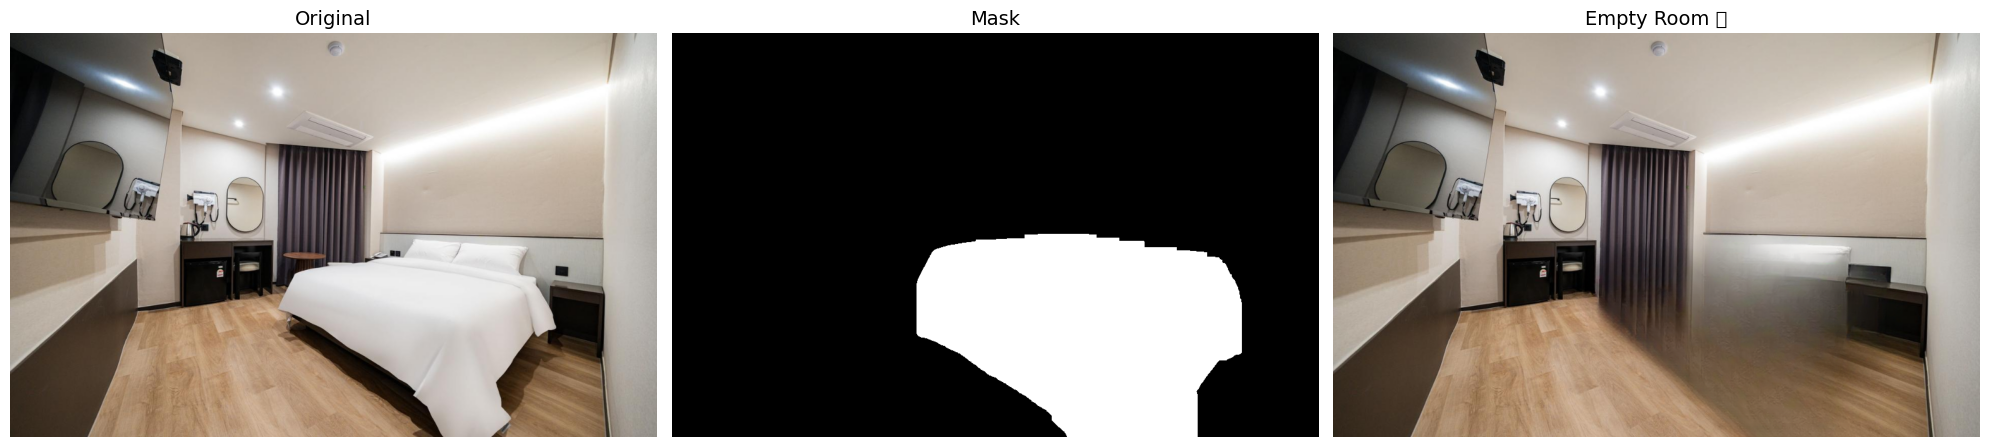

✅ 완료! Drive에 저장됨: /content/drive/MyDrive/furniture_remover/outputs
결과가 맘에 들면 셀 6 실행!


In [4]:
# ============================================================
# 셀 5: LaMa 인페인팅 (가구 제거)
# ============================================================
import torch

def run_lama(image_np, mask_np):
    img = image_np.astype(np.float32) / 255.0
    msk = (mask_np > 127).astype(np.float32)
    img_t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).cuda()
    msk_t = torch.from_numpy(msk).unsqueeze(0).unsqueeze(0).cuda()
    with torch.no_grad():
        batch  = {'image': img_t, 'mask': msk_t}
        batch  = lama_model(batch)
        result = batch['inpainted'][0].permute(1, 2, 0).cpu().numpy()
        result = (result * 255).clip(0, 255).astype(np.uint8)
    return result

print('🎨 LaMa 인페인팅 실행 중...')
result = run_lama(image_np, mask_np)

# Drive에 저장
OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Image.fromarray(result).save(f'{OUTPUT_DIR}/empty_room.jpg')
Image.fromarray(image_np).save(f'{OUTPUT_DIR}/original.jpg')
Image.fromarray(mask_np).save(f'{OUTPUT_DIR}/mask.png')

# 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(image_np)
axes[0].set_title('Original', fontsize=14)
axes[0].axis('off')
axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title('Mask', fontsize=14)
axes[1].axis('off')
axes[2].imshow(result)
axes[2].set_title('Empty Room ✅', fontsize=14)
axes[2].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison.png', dpi=150)
plt.show()

print(f'✅ 완료! Drive에 저장됨: {OUTPUT_DIR}')
print('결과가 맘에 들면 셀 6 실행!')

In [ ]:
# ============================================================
# 셀 6: Stable Diffusion Inpainting (뿌연 자리 자연스럽게 채우기)
# ============================================================
!pip install -q diffusers transformers accelerate

from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 모델 로드
print('🤖 SD Inpainting 모델 로드 중... (최초 1~2분)')
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")
print('✅ 모델 로드 완료!')

# 이미지 & 마스크 로드 (셀 5 결과물 사용)
OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
image_pil = Image.open(f'{OUTPUT_DIR}/empty_room.jpg').convert('RGB')
mask_pil  = Image.open(f'{OUTPUT_DIR}/mask.png').convert('L')

# 8의 배수로 리사이즈 (SD 필수 조건)
W, H = image_pil.size
new_w = (W // 8) * 8
new_h = (H // 8) * 8
image_pil = image_pil.resize((new_w, new_h))
mask_pil  = mask_pil.resize((new_w, new_h))

# 마스크 살짝 팽창 (경계 자연스럽게)
mask_np = np.array(mask_pil)
kernel  = np.ones((20, 20), np.uint8)
mask_np = cv2.dilate(mask_np, kernel, iterations=1)

🤖 SD Inpainting 모델 로드 중... (최초 1~2분)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors not found


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

...

diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✅ 모델 로드 완료!


🎨 AI로 빈 공간 채우는 중...


  0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11898/1976161266.py:57: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.

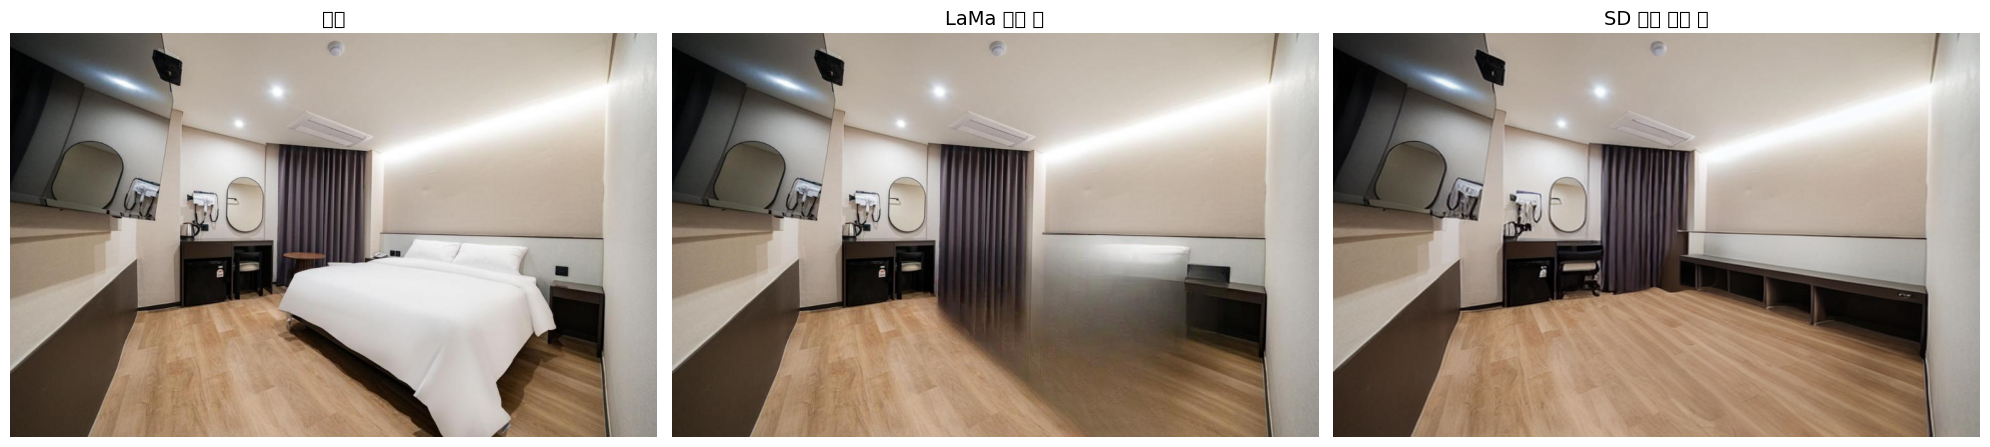

📸 최종 결과:


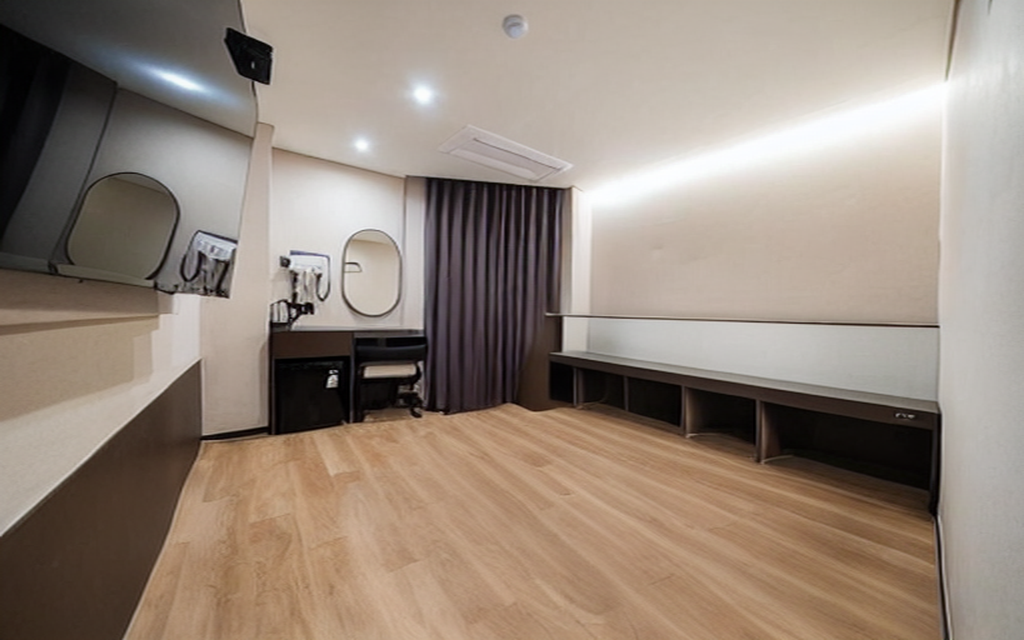

✅ Drive 저장 완료: /content/drive/MyDrive/furniture_remover/outputs/final_result.jpg


In [9]:
# 셀 7 맨 위에 추가
from diffusers import StableDiffusionInpaintPipeline
import torch

if 'pipe' not in dir():
    print('⚠️ pipe 없음 - 재로드 중...')
    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        'runwayml/stable-diffusion-inpainting',
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to('cuda')
    print('✅ pipe 재로드 완료!')
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display

OUTPUT_DIR = f'{DRIVE_DIR}/outputs'
image_pil = Image.open(f'{OUTPUT_DIR}/empty_room.jpg').convert('RGB')
mask_pil  = Image.open(f'{OUTPUT_DIR}/mask.png').convert('L')

W, H = image_pil.size
new_w = (W // 8) * 8
new_h = (H // 8) * 8
image_pil = image_pil.resize((new_w, new_h))
mask_pil  = mask_pil.resize((new_w, new_h))

mask_np = np.array(mask_pil)
kernel  = np.ones((20, 20), np.uint8)
mask_np = cv2.dilate(mask_np, kernel, iterations=1)
mask_pil = Image.fromarray(mask_np)

print('🎨 AI로 빈 공간 채우는 중...')
result = pipe(
    prompt="empty room, clean wooden floor, bright interior, realistic, high quality, seamless",
    negative_prompt="furniture, bed, sofa, blurry, dark, distorted",
    image=image_pil,
    mask_image=mask_pil,
    num_inference_steps=50,
    guidance_scale=8.0,
    strength=0.95,
).images[0]
result = result.resize((W, H), Image.LANCZOS)  # 원본 크기로 복원!
result.save(f'{OUTPUT_DIR}/final_result.jpg')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(np.array(Image.open(f'{OUTPUT_DIR}/original.jpg')))
axes[0].set_title('원본', fontsize=14)
axes[0].axis('off')
axes[1].imshow(np.array(image_pil))
axes[1].set_title('LaMa 제거 후', fontsize=14)
axes[1].axis('off')
axes[2].imshow(np.array(result))
axes[2].set_title('SD 최종 결과 ✅', fontsize=14)
axes[2].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_comparison.png', dpi=150)
plt.show()

print('📸 최종 결과:')
display(result)
print(f'✅ Drive 저장 완료: {OUTPUT_DIR}/final_result.jpg')

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
